# NorthBay Living — Risk Scoring (Workflow Step 9)

Turns the forecast from `04_ml_forecast.ipynb` (Random Forest — best panel WAPE, 0.213) into
an operational **Reorder / Hold / Clear** flag per store-product, using the classic
inventory metric **days-of-cover**:

`days_of_cover = current_inventory / avg_daily_demand_forecast`

- Low cover -> stockout risk -> **Reorder**
- High cover -> overstock risk -> **Clear**
- In between -> **Hold**

Thresholds are percentile-based (10th / 90th), same approach the EDA notebook used, but
recomputed here on the current forecasted days-of-cover rather than the historical rolling
average — this is the number that should actually drive today's reorder decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
print("Libraries loaded.")

Libraries loaded.


## Step 1 — Load latest inventory snapshot, latest prices, and the model forecast

In [2]:
inventory = pd.read_csv('../Cleaned + Splitted/inventory_snapshots_cleaned_v2.csv', parse_dates=['date'])
sales = pd.read_csv('../Cleaned + Splitted/sales_daily_cleaned_v2.csv', parse_dates=['date'])
sku = pd.read_csv('../Cleaned + Splitted/sku_master_cleaned_v2.csv')
forecast = pd.read_csv('../CSV Outputs/ml_forecast_holdout.csv', parse_dates=['week'])

# Latest inventory snapshot = today's stock position
latest_date = inventory['date'].max()
latest_inventory = inventory[inventory['date'] == latest_date][['store_id', 'product_id', 'inventory_level']]
print(f"Latest inventory snapshot date: {latest_date.date()}  ({len(latest_inventory)} store-product rows)")

# Latest price per store-product (most recent sales row)
latest_price = (sales.sort_values('date')
                 .groupby(['store_id', 'product_id'])['price'].last()
                 .reset_index())

# Most recent forecast week = closest thing we have to "next week's expected demand"
latest_forecast_week = forecast['week'].max()
next_week_forecast = forecast[forecast['week'] == latest_forecast_week][['store_id', 'product_id', 'rf_forecast']]
print(f"Using forecast week: {latest_forecast_week.date()} as the near-term demand signal")

Latest inventory snapshot date: 2024-01-30  (100 store-product rows)
Using forecast week: 2024-01-22 as the near-term demand signal


## Step 2 — Build the risk table

In [3]:
risk = (latest_inventory
        .merge(next_week_forecast, on=['store_id', 'product_id'], how='left')
        .merge(latest_price, on=['store_id', 'product_id'], how='left')
        .merge(sku, on=['store_id', 'product_id'], how='left'))

risk['avg_daily_demand_forecast'] = (risk['rf_forecast'] / 7).clip(lower=0.1)  # floor avoids /0
risk['days_of_cover'] = risk['inventory_level'] / risk['avg_daily_demand_forecast']

print("Missing values after merge:\n", risk.isnull().sum())
risk.head()

Missing values after merge:
 store_id                     0
product_id                   0
inventory_level              0
rf_forecast                  0
price                        0
category                     0
region                       0
avg_daily_demand_forecast    0
days_of_cover                0
dtype: int64


,store_id,product_id,inventory_level,rf_forecast,price,category,region,avg_daily_demand_forecast,days_of_cover
0,S001,P0001,383,625.211033,71.56,Electronics,North,89.315862,4.288152
1,S001,P0002,136,710.740513,70.55,Clothing,North,101.534359,1.339448
2,S001,P0003,434,774.185532,59.46,Clothing,North,110.597933,3.924124
3,S001,P0004,241,712.286804,93.82,Electronics,North,101.755258,2.368428
4,S001,P0005,946,739.012297,45.82,Groceries,North,105.573185,8.960609


## Step 3 — Percentile-based thresholds and flags

In [4]:
low_threshold = risk['days_of_cover'].quantile(0.10)
high_threshold = risk['days_of_cover'].quantile(0.90)
print(f"Reorder threshold (10th pct): {low_threshold:.2f} days")
print(f"Clear threshold   (90th pct): {high_threshold:.2f} days")

def flag_risk(days):
    if days <= low_threshold:
        return 'Reorder'
    elif days >= high_threshold:
        return 'Clear'
    else:
        return 'Hold'

risk['risk_flag'] = risk['days_of_cover'].apply(flag_risk)
print(risk['risk_flag'].value_counts())

Reorder threshold (10th pct): 1.10 days
Clear threshold   (90th pct): 5.96 days
risk_flag
Hold       80
Clear      10
Reorder    10
Name: count, dtype: int64


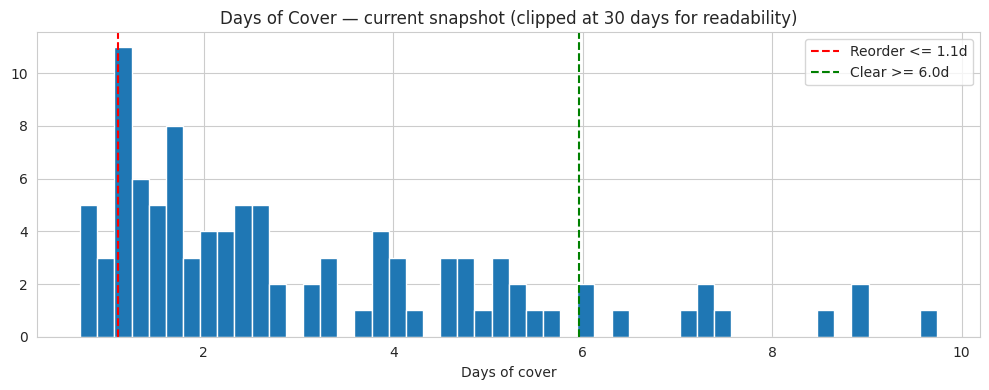

In [5]:
plt.figure(figsize=(10, 4))
risk['days_of_cover'].clip(upper=30).hist(bins=50)
plt.axvline(low_threshold, color='red', linestyle='--', label=f'Reorder <= {low_threshold:.1f}d')
plt.axvline(high_threshold, color='green', linestyle='--', label=f'Clear >= {high_threshold:.1f}d')
plt.title('Days of Cover — current snapshot (clipped at 30 days for readability)')
plt.xlabel('Days of cover'); plt.legend()
plt.tight_layout(); plt.show()

## Step 4 — Where is the risk concentrated? (store / category)

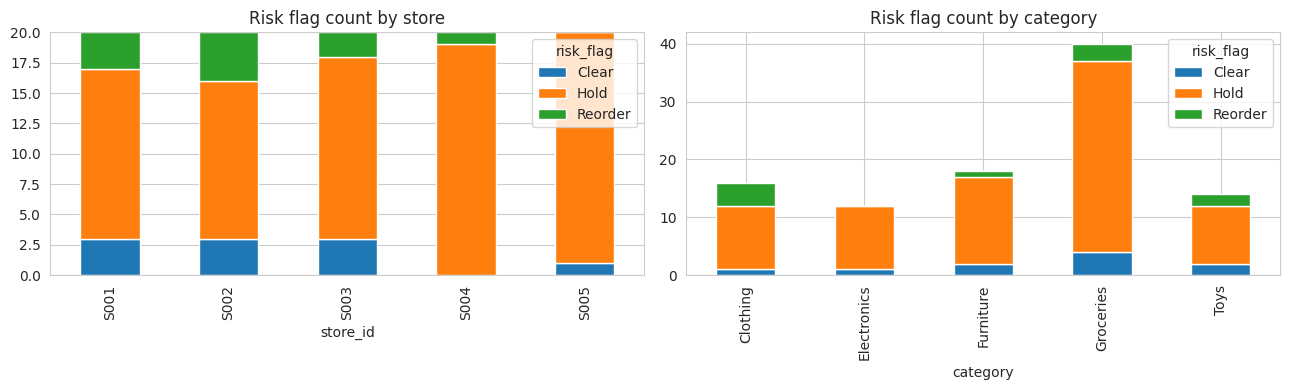

store_id product_id    category  inventory_level  avg_daily_demand_forecast  days_of_cover risk_flag
    S002      P0018    Clothing               61                  87.838186       0.694459   Reorder
    S002      P0011   Groceries               73                 104.735709       0.696992   Reorder
    S002      P0008   Groceries               85                  99.888803       0.850946   Reorder
    S002      P0016    Clothing               88                 102.019171       0.862583   Reorder
    S001      P0015        Toys               80                  92.724491       0.862771   Reorder
    S001      P0013        Toys               91                  92.654524       0.982143   Reorder
    S003      P0020    Clothing              113                 111.566216       1.012851   Reorder
    S003      P0019   Groceries              108                 103.150467       1.047014   Reorder
    S001      P0009    Clothing              128                 118.671870       1.078604 

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pd.crosstab(risk['store_id'], risk['risk_flag']).plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Risk flag count by store')
pd.crosstab(risk['category'], risk['risk_flag']).plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Risk flag count by category')
plt.tight_layout(); plt.show()

print(risk[risk['risk_flag'] != 'Hold'].sort_values('days_of_cover')[
    ['store_id', 'product_id', 'category', 'inventory_level', 'avg_daily_demand_forecast', 'days_of_cover', 'risk_flag']
].to_string(index=False))

## Step 5 — ₹ impact of the flags

Same rough-estimate approach as the EDA notebook's Part G, refined here with the actual
forecast instead of a rolling average:

- **Capital locked** in `Clear`-flagged stock (money tied up in inventory that's moving too slowly).
- **Revenue at risk** on `Reorder`-flagged stock (a 7-day horizon: forecasted demand the current
  stock won't cover, valued at current price).

In [7]:
risk['capital_locked'] = np.where(risk['risk_flag'] == 'Clear', risk['inventory_level'] * risk['price'], 0)
risk['revenue_at_risk'] = np.where(
    risk['risk_flag'] == 'Reorder',
    (risk['avg_daily_demand_forecast'] * 7 - risk['inventory_level']).clip(lower=0) * risk['price'],
    0
)

print(f"Total capital locked in 'Clear' stock:    Rs.{risk['capital_locked'].sum():,.0f}")
print(f"Total revenue at risk in 'Reorder' stock:  Rs.{risk['revenue_at_risk'].sum():,.0f}")

top_risk = risk[risk['risk_flag'] != 'Hold'].sort_values(
    ['revenue_at_risk', 'capital_locked'], ascending=False
)[['store_id', 'product_id', 'category', 'risk_flag', 'days_of_cover', 'capital_locked', 'revenue_at_risk']]
top_risk.head(10)

Total capital locked in 'Clear' stock:    Rs.552,219
Total revenue at risk in 'Reorder' stock:  Rs.378,389


,store_id,product_id,category,risk_flag,days_of_cover,capital_locked,revenue_at_risk
8,S001,P0009,Clothing,Reorder,1.078604,0.0,63489.224064
35,S002,P0016,Clothing,Reorder,0.862583,0.0,57291.278776
79,S004,P0020,Furniture,Reorder,1.088875,0.0,56837.282160
30,S002,P0011,Groceries,Reorder,0.696992,0.0,55320.567034
59,S003,P0020,Clothing,Reorder,1.012851,0.0,47158.223997
58,S003,P0019,Groceries,Reorder,1.047014,0.0,37733.573552
12,S001,P0013,Toys,Reorder,0.982143,0.0,18823.957158
37,S002,P0018,Clothing,Reorder,0.694459,0.0,17264.043695
27,S002,P0008,Groceries,Reorder,0.850946,0.0,16571.699341
14,S001,P0015,Toys,Reorder,0.862771,0.0,7898.711529


## Step 6 — Save output for the dashboard

In [8]:
risk_out = risk[['store_id', 'product_id', 'category', 'region', 'inventory_level',
                  'avg_daily_demand_forecast', 'days_of_cover', 'risk_flag',
                  'capital_locked', 'revenue_at_risk']].sort_values('days_of_cover')

risk_out.to_csv('../CSV Outputs/risk_scoring_results.csv', index=False)
print("Saved: risk_scoring_results.csv")
print(f"Snapshot date: {latest_date.date()}  |  Forecast week: {latest_forecast_week.date()}")
risk_out.head()

Saved: risk_scoring_results.csv
Snapshot date: 2024-01-30  |  Forecast week: 2024-01-22


,store_id,product_id,category,region,inventory_level,avg_daily_demand_forecast,days_of_cover,risk_flag,capital_locked,revenue_at_risk
37,S002,P0018,Clothing,South,61,87.838186,0.694459,Reorder,0.0,17264.043695
30,S002,P0011,Groceries,South,73,104.735709,0.696992,Reorder,0.0,55320.567034
27,S002,P0008,Groceries,South,85,99.888803,0.850946,Reorder,0.0,16571.699341
35,S002,P0016,Clothing,South,88,102.019171,0.862583,Reorder,0.0,57291.278776
14,S001,P0015,Toys,North,80,92.724491,0.862771,Reorder,0.0,7898.711529


## Summary — Step 9 (Risk Scoring) delivered

| Item | Result |
|---|---|
| Input forecast | Random Forest (best panel model from `04_ml_forecast.ipynb`, WAPE 0.213) |
| Metric | Days of cover = current inventory / forecasted avg daily demand |
| Thresholds | 10th pct (Reorder) / 90th pct (Clear), recomputed on the current snapshot |
| Output | `risk_scoring_results.csv` — one row per store-product with flag + Rs. impact |
| Business use | Reorder list = stockout risk this week; Clear list = capital to free up |

**Next step (workflow item 10):** package the forecast + risk table into the Streamlit
dashboard (Home, Sales Analytics, Forecast, Inventory, Risk, Product Details, Executive
Summary pages, per the course's dashboard flow doc).